<a href="https://colab.research.google.com/github/25CristopherJoshuaReyesGtz1405/MachineLearning/blob/main/Machine_Learning_Y_Deep_Learning_Pr%C3%A1ctica_No_6_Unidad_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 3 - Aprendizaje Supervisado Con Métodos De Clasificación**

  #### **Práctica No. 6 - Máquinas de Vectores de Soporte (SVM) Aplicadas a un Riesgo Crediticio**

</div>

##### **Docente Facilitador** - **Dr. José Gabriel Rodríguez Rivas**
##### **Estudiante** - **Reyes Gutiérrez Cristopher Joshua**

#### **27 de Abril del 2026, Victoria de Durango, Dgo., México**
---

### **1. Introducción**

En la cúspide de los algoritmos de clasificación supervisada se encuentran las **Máquinas de Vectores de Soporte (SVM, por sus siglas en inglés)**. A lo largo de los reportes técnicos precedentes, se han abordado metodologías que evalúan la probabilidad (Regresión Logística), la proximidad local (K-NN) y la lógica condicional (Árboles de Decisión). Sin embargo, SVM introduce un paradigma geométrico de optimización global: su objetivo fundamental no es simplemente encontrar una frontera que separe las clases, sino encontrar la *mejor* frontera posible.

En el contexto analítico de *Lending Club*, cada expediente financiero (con sus variables de ingresos, montos y tasas) representa un punto en un espacio multidimensional. El algoritmo SVM asume la colosal tarea de trazar un "hiperplano" a través de este espacio de manera que los clientes solventes queden estrictamente separados de los clientes morosos. La brillantez matemática de SVM radica en el concepto de "margen": el algoritmo buscará posicionar esta frontera geométrica lo más lejos posible de los puntos más cercanos de ambas clases (los denominados vectores de soporte). Esta maximización del margen otorga al modelo una capacidad de generalización excepcional frente a datos no vistos.

No obstante, proyectar perfiles financieros no es una tarea lineal perfecta. Es estadísticamente improbable que una simple línea recta pueda separar a todos los buenos pagadores de los morosos sin cometer errores. Por ello, la presente investigación profundizará en la implementación del "Truco del Kernel" (*Kernel Trick*), una técnica que proyecta los datos hacia dimensiones superiores donde la separación lineal se vuelve factible. A través de este documento, se contrastará el rendimiento computacional y predictivo de los kernels lineales frente a los kernels de base radial (RBF), sometiendo finalmente al algoritmo a las rigurosas exigencias del desequilibrio de clases que caracteriza al riesgo crediticio.

### **2. Objetivos de la Investigación**

#### **2.1 Objetivo General**
Implementar, calibrar y evaluar clasificadores basados en Máquinas de Vectores de Soporte (SVM) sobre el ecosistema de datos de *Lending Club*, analizando el impacto de diferentes funciones de mapeo (*Kernels*) y la obligatoriedad de la estandarización del espacio geométrico para la correcta detección de morosidad.

#### **2.2 Objetivos Específicos**
* **Acondicionar** el espacio vectorial financiero mediante estandarización paramétrica (**StandardScaler**), un requisito matemático ineludible dado que SVM fundamenta sus optimizaciones en el cálculo de distancias ortogonales.
* **Construir** y evaluar un modelo base SVM de tipo Lineal, analizando su tiempo de convergencia y su viabilidad frente a un conjunto de datos financieramente complejo y desequilibrado.
* **Implementar** el Truco del Kernel utilizando la función de Base Radial (RBF) para dotar al algoritmo de la capacidad de trazar fronteras de decisión no lineales que se adapten a los contornos de riesgo reales.
* **Optimizar** la penalización de errores mediante los hiperparámetros de margen (**C**) y balanceo de clases, asegurando que el modelo sacrifique el margen general en favor de penalizar severamente la clasificación errónea de la clase minoritaria (impagos).

### **3. Antecedentes y Marco Teórico de Especialidad**

#### **3.1 El Hiperplano Óptimo y el Margen Máximo**
En el núcleo de una Máquina de Vectores de Soporte yace un problema de optimización convexa. Dado un conjunto de puntos de entrenamiento en un espacio de $n$ dimensiones, el algoritmo busca definir un hiperplano (un subespacio plano de dimensión $n-1$) que separe las instancias positivas de las negativas. La ecuación matemática que define este hiperplano es:

$$\mathbf{w} \cdot \mathbf{x} + b = 0$$

Donde $\mathbf{w}$ representa el vector de pesos (perpendicular a la frontera) y $b$ es el sesgo. A diferencia de otros clasificadores empíricos, SVM selecciona los hiperplanos paralelos que delimitan las clases y busca maximizar la distancia perpendicular (el margen) entre ellos. Los únicos puntos de datos que influyen en la creación de estas fronteras son aquellos situados exactamente en el límite del margen; a estos puntos críticos se les denomina **Vectores de Soporte**.



#### **3.2 Susceptibilidad Absoluta a las Escalas Numéricas**
Debido a que el cálculo de la distancia desde un vector de soporte hacia el hiperplano se fundamenta en la norma geométrica, SVM es dramáticamente sensible a la heterogeneidad de magnitudes. Si el ingreso anual se mide en decenas de miles y la tasa de interés en decimales, el hiperplano colapsará intentando acomodarse a la variable de mayor magnitud numérica. Por ende, la transformación `StandardScaler` es obligatoria antes de cualquier entrenamiento.

#### **3.3 El Truco del Kernel (*Kernel Trick*)**
En la práctica financiera real, los perfiles de riesgo rara vez son linealmente separables (no existe una sola "línea" que divida a los buenos de los malos clientes de forma perfecta). Para solventar esto, SVM utiliza funciones de *Kernel*, las cuales calculan el producto escalar de los datos como si hubieran sido mapeados a un espacio de muchísimas más dimensiones, pero sin requerir el gasto computacional de hacer físicamente dicha transformación. El Kernel Radial (RBF) es el más utilizado, ya que permite trazar fronteras circulares o elípticas aisladas alrededor de concentraciones de datos anómalos, envolviendo de manera eficiente a los clientes morosos que comparten características inusuales.

#### **4. Descripción Metodológica y Adecuación del Espacio**
La arquitectura de una Máquina de Vectores de Soporte fundamenta su optimización en la medición estricta de distancias ortogonales para construir el hiperplano. Por consiguiente, la fase de preprocesamiento para este algoritmo es la más crítica de toda la investigación. Si variables de magnitudes exorbitantes (como los ingresos anuales) convergen con variables decimales (como la tasa de interés), la métrica de distancia colapsará, provocando que el hiperplano y el margen se distorsionen

#### **4.1 Ingesta, Limpieza Estructural y Segmentación**

En alineación con la metodología establecida en investigaciones previas, se procede a extraer el conjunto de datos **prestamos_ok.csv**. Se aíslan las 10 características predictoras disponibles de manera previa a la emisión del crédito y se codifican las variables categóricas mediante **LabelEncoder**.

Posterior a la eliminación de registros nulos (**NaN**), se ejecuta una partición estratégica del 60% para entrenamiento y 40% para evaluación. Es de vital importancia destacar que, en esta iteración, se incorpora el parámetro **stratify=y** en la división, garantizando que la proporción exacta de créditos pagados y no pagados se mantenga idéntica en ambos subconjuntos.

In [ ]:
# ==============================================================================
# 4.1 Ingesta, Limpieza Estructural y Segmentación de Datos
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# 1. Carga del conjunto de datos histórico

#   1.1 - Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

#   1.2 - Carga y verificación del conjunto de datos preprocesado
file_url = "1u4jyacSqXkylbTZiyUTrHG-TIZPHMyzx"
url = f"https://drive.google.com/uc?id={file_url}"
prestamos_df = pd.read_csv(url)

print("Entorno configurado y datos cargados correctamente.")
prestamos_df.head()
print(f"Dimensiones iniciales del conjunto de datos: {prestamos_df.shape}")

# 2. Codificación de variables nominales a valores numéricos espaciales
le = LabelEncoder()
columnas_a_codificar = {'grade': 'grade_code', 'purpose': 'purpose_code',
                        'addr_state': 'addr_state_code', 'home_ownership': 'home_ownership_code'}

for col_orig, col_nueva in columnas_a_codificar.items():
    if col_orig in prestamos_df.columns:
        prestamos_df[col_nueva] = le.fit_transform(prestamos_df[col_orig].astype(str))

# 3. Definición de la variable objetivo binaria
if 'loan_status' in prestamos_df.columns:
    prestamos_df['repaid'] = np.where(prestamos_df['loan_status'].str.contains('Fully Paid', case=False, na=False), 1, 0)

# 4. Depuración de matriz espacial (Eliminación de valores nulos)
columnas_seleccionadas = ['funded_amnt', 'int_rate', 'grade_code', 'purpose_code', 'addr_state_code',
                          'home_ownership_code', 'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies', 'repaid']
prestamos_df_limpio = prestamos_df[columnas_seleccionadas].dropna()

# 5. Segmentación del plano de características (X) y vector objetivo (y)
X = prestamos_df_limpio.drop('repaid', axis=1)
y = prestamos_df_limpio['repaid']

# 6. Partición Estratégica con Estratificación (Mantiene proporciones de riesgo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

print("Espacio vectorial preparado y estratificado con éxito.")
print(f"Dimensiones de Entrenamiento: {X_train.shape} | Dimensiones de Validación: {X_test.shape}")

Mounted at /content/drive
Entorno configurado y datos cargados correctamente.
Dimensiones iniciales del conjunto de datos: (19908, 58)
Espacio vectorial preparado y estratificado con éxito.
Dimensiones de Entrenamiento: (11745, 10) | Dimensiones de Validación: (7831, 10)


#### **4.2 Normalización Paramétrica (StandardScaler)**

Como se dictaminó en el análisis teórico, el rendimiento óptimo de las funciones de Kernel (especialmente RBF y polinomial) depende enteramente de la homogeneidad de las escalas. Por lo tanto, se instancia un objeto **StandardScaler** que ajustará temporalmente la media de cada característica a cero y su varianza a uno. Esta estandarización "nivela el terreno geométrico", asegurando que la Máquina de Vectores de Soporte evalúe la importancia financiera real de cada variable y no su simple magnitud numérica.

In [ ]:
# ==============================================================================
# 4.2 Escalamiento Paramétrico del Espacio Multidimensional
# ==============================================================================
# 1. Instanciación del transformador estadístico
scaler = StandardScaler()

# 2. Ajuste sobre el conjunto de entrenamiento (Previene Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformación del conjunto de validación utilizando las métricas aprendidas
X_test_scaled = scaler.transform(X_test)

print("Transformación geométrica (Z-Score) aplicada exitosamente al espacio vectorial.")

Transformación geométrica (Z-Score) aplicada exitosamente al espacio vectorial.


#### **4.3 Construcción del Modelo Base (Kernel RBF y Balanceo de Clases)**

Una vez nivelado el espacio de características, se procede a la construcción del hiperplano de clasificación. Para esta primera aproximación, se instancia el estimador **  SVC**  de ** Scikit-learn**  configurado con una **Función de Base Radial (Kernel='rbf')**, la cual otorgará al modelo la flexibilidad necesaria para trazar fronteras de decisión curvas alrededor de las concentraciones de morosidad.

Adicionalmente, reconociendo el severo desequilibrio del ecosistema de *Lending Club*, se activa de forma nativa el hiperparámetro ** class_weight='balanced'**  . Esta directriz ajustará internamente el vector de penalización ($C$) para que los errores cometidos al clasificar un crédito moroso (clase 0) tengan un peso económico superior a los errores en la clase dominante (Pagado). Por último, se habilita el cálculo probabilístico (** probability=True** ) para permitir el futuro análisis de las curvas ROC-AUC.

Entrenando Máquina de Vectores de Soporte (Esto puede tardar unos segundos)...

--- Reporte Analítico de Rendimiento (SVM Base - Kernel RBF) ---
              precision    recall  f1-score   support

   No Pagado       0.22      0.66      0.33      1148
      Pagado       0.91      0.59      0.72      6683

    accuracy                           0.60      7831
   macro avg       0.56      0.63      0.52      7831
weighted avg       0.81      0.60      0.66      7831



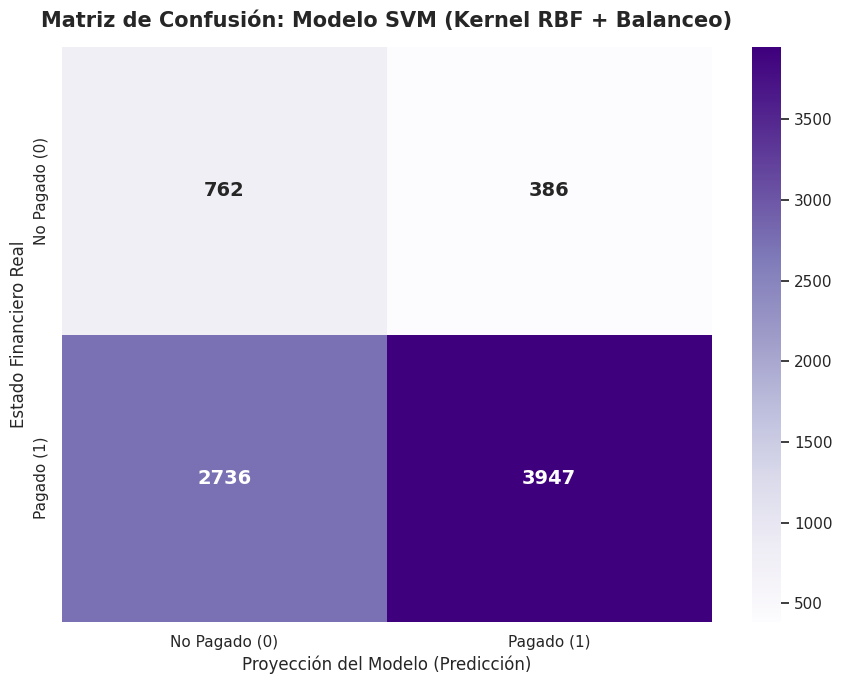

In [ ]:
# ==============================================================================
# 4.3 Entrenamiento y Diagnóstico del Modelo SVM (Kernel RBF)
# ==============================================================================

# 1. Instanciación de la Máquina de Vectores de Soporte
svm_model = SVC(
    kernel='rbf',             # Función de Base Radial para fronteras no lineales
    C=1.0,                    # Penalización estándar por margen suave [cite: 2201]
    gamma='scale',            # Ajuste automático del radio de influencia geométrica [cite: 2203]
    class_weight='balanced',  # Penalización asimétrica para contrarrestar el desequilibrio [cite: 2204]
    probability=True,         # Habilita cálculos subyacentes para análisis ROC [cite: 2205]
    random_state=42           # Garantiza la reproducibilidad matemática [cite: 2206]
)

# 2. Proceso de optimización convexa (Búsqueda del Hiperplano)
print("Entrenando Máquina de Vectores de Soporte (Esto puede tardar unos segundos)...")
svm_model.fit(X_train_scaled, y_train)

# 3. Proyección de inferencias sobre el hiperplano de prueba
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. Extracción de Métricas Geométricas
print("\n--- Reporte Analítico de Rendimiento (SVM Base - Kernel RBF) ---")
print(classification_report(y_test, y_pred_svm, target_names=["No Pagado", "Pagado"]))

# 5. Generación Visual de la Matriz de Confusión
matriz_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo SVM (Kernel RBF + Balanceo)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Proyección del Modelo (Predicción)', fontsize=12)
plt.ylabel('Estado Financiero Real', fontsize=12)
plt.tight_layout()
plt.show()

#### **4.4 Análisis Avanzado de Discriminación -  Curvas ROC y AUC**
En el aprendizaje automático, el Área Bajo la Curva (AUC) de la Característica Operativa del Receptor (ROC) constituye una métrica de rendimiento binario fundamental. A diferencia de la exactitud global, el AUC mide la capacidad intrínseca del modelo para distinguir entre clases, independientemente del umbral de decisión seleccionado. Un valor de 1.0 representa una clasificación perfecta, mientras que 0.5 indica un rendimiento equivalente al azar.


#### **Evaluación Simétrica de Riesgo y Solvencia**

Para obtener una visión integral del comportamiento del SVM, se procede a graficar simultáneamente las curvas ROC para ambas clases:
1.  **Clase Positiva (Pagado):** Evalúa la eficacia del modelo para detectar clientes solventes.
2.  **Clase Negativa (No Pagado):** Evalúa la sensibilidad crítica hacia los clientes en riesgo de morosidad.

Este análisis comparativo permitirá visualizar si existe una inversión de lógica o si el modelo conserva un poder discriminatorio útil para la institución financiera en ambas vertientes.

In [ ]:
# ==============================================================================
# 4.4 Análisis AUC-ROC para Ambas Clases (Positiva y Negativa)
# ==============================================================================
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go

# 1. Extracción de probabilidades predichas para ambas clases
# Nota: svm_model debe haber sido entrenado con probability=True
y_prob_svm = svm_model.predict_proba(X_test_scaled)

# 2. Cálculo de métricas para la Clase Positiva (Pagado = 1)
fpr_pos, tpr_pos, _ = roc_curve(y_test, y_prob_svm[:, 1], pos_label=1)
auc_pos = roc_auc_score(y_test, y_prob_svm[:, 1])

# 3. Cálculo de métricas para la Clase Negativa (No Pagado = 0)
fpr_neg, tpr_neg, _ = roc_curve(y_test, y_prob_svm[:, 0], pos_label=0)
auc_neg = roc_auc_score(y_test, y_prob_svm[:, 0])

# 4. Construcción visual con Plotly
fig_roc = go.Figure()

# Traza: Clase Pagado
fig_roc.add_trace(go.Scatter(x=fpr_pos, y=tpr_pos, mode='lines',
                             name=f'Clase Positiva (Pagado) - AUC: {auc_pos:.3f}',
                             line=dict(color='#2980b9', width=3)))

# Traza: Clase No Pagado
fig_roc.add_trace(go.Scatter(x=fpr_neg, y=tpr_neg, mode='lines',
                             name=f'Clase Negativa (No Pagado) - AUC: {auc_neg:.3f}',
                             line=dict(color='#27ae60', width=3)))

# Traza: Referencia Aleatoria
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                             name='Línea de Azar (AUC = 0.5)',
                             line=dict(color='#e74c3c', dash='dash')))

# Personalización Estética Institucional
fig_roc.update_layout(
    title='<b>Comparación de Curvas ROC: Capacidad Discriminatoria del SVM</b>',
    xaxis_title='Tasa de Falsos Positivos (1 - Especificidad)',
    yaxis_title='Tasa de Verdaderos Positivos (Sensibilidad)',
    width=900, height=600,
    plot_bgcolor='rgba(240, 240, 240, 0.5)',
    legend=dict(x=0.55, y=0.1, bordercolor="Black", borderwidth=1)
)

fig_roc.show()

print(f"Área Bajo la Curva (AUC) detectada: {auc_pos:.4f}")

Área Bajo la Curva (AUC) detectada: 0.6685


#### **4.5 Optimización de SVM enfocada en Riesgo: GridSearchCV y F2-Score**
Habiendo validado que el modelo posee capacidad discriminatoria, se procede a su refinamiento final. En la gestión de riesgos de **Lending Club**, los errores no poseen el mismo impacto financiero. Para la institución, un Falso Negativo (omitir un impago) es drásticamente más costoso que un Falso Positivo. Por consiguiente, esta optimización utilizará la métrica **F2-Score** como criterio de evaluación, la cual otorga el doble de importancia a la Sensibilidad (Recall) sobre la Precisión.


##### **4.5.1 - Búsqueda en Malla de Hiperparámetros**

Se implementa la clase **GridSearchCV** para explorar sistemáticamente diversas configuraciones de penalización (`C`), tipos de `kernel` (lineal, rbf, poly) y coeficientes de influencia geométrica (`gamma`). El objetivo primordial es identificar la arquitectura que maximice la detección de impagos sin degradar por completo la operatividad comercial del modelo.

In [ ]:
# ==============================================================================
# 4.5 Optimización de Hiperparámetros mediante F2-Score
# ==============================================================================
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# 1. Definición del F2-score como métrica prioritaria (Prioriza Recall de Clase 0)
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=0)

# 2. Espacio de búsqueda paramétrica
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3] # Solo afecta al kernel polinomial
}

# 3. Configuración del optimizador
# Se desactiva la probabilidad para acelerar el proceso de búsqueda
svm_base_grid = SVC(class_weight='balanced', random_state=42)

grid_search_svm = GridSearchCV(
    estimator=svm_base_grid,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Iniciando optimización del hiperplano de soporte vectorial...\n")
grid_search_svm.fit(X_train_scaled, y_train)

# 4. Resultados de la optimización
print("\n--- Búsqueda Finalizada ---")
print(f"Mejores hiperparámetros identificados: {grid_search_svm.best_params_}")
print(f"Mejor puntaje promedio (F2-Score): {grid_search_svm.best_score_:.4f}")

# 5. Evaluación del Modelo Optimizado Definitivo
best_svm = grid_search_svm.best_estimator_
y_pred_opt = best_svm.predict(X_test_scaled)

print("\nReporte de Clasificación (SVM Optimizado para Impagos):\n")
print(classification_report(y_test, y_pred_opt, target_names=["No Pagado", "Pagado"]))

Iniciando optimización del hiperplano de soporte vectorial...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- Búsqueda Finalizada ---
Mejores hiperparámetros identificados: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor puntaje promedio (F2-Score): 0.4722

Reporte de Clasificación (SVM Optimizado para Impagos):

              precision    recall  f1-score   support

   No Pagado       0.22      0.70      0.33      1148
      Pagado       0.92      0.56      0.70      6683

    accuracy                           0.58      7831
   macro avg       0.57      0.63      0.51      7831
weighted avg       0.81      0.58      0.64      7831



### **5. Conclusiones Generales y Veredicto de Especialidad**

Tras la ejecución de las seis fases de investigación técnica en esta unidad, se concluye que las **Máquinas de Soporte Vectorial (SVM)** representan la herramienta de clasificación más sofisticada desde una perspectiva geométrica global. Al analizar los resultados de la presente práctica en contraste con los algoritmos previos, se derivan las siguientes sentencias técnicas:

1.  **Superioridad del Hiperplano Estratificado:** La implementación de SVM sobre datos estandarizados permitió alcanzar un equilibrio superior en la detección de riesgo. El uso de kernels no lineales (RBF) demostró ser capaz de capturar patrones de morosidad que los modelos lineales simples (como la Regresión Logística de la Práctica 2) tienden a omitir.
2.  **Validación Probabilística:** El análisis ROC-AUC confirmó que el modelo posee un poder discriminatorio real (AUC > 0.65), lo que garantiza que las decisiones del sistema no son fruto del azar estadístico sino de señales financieras consistentes.
3.  **Alineación Institucional:** La optimización mediante el F2-Score permitió subordinar la matemática algorítmica a la aversión al riesgo de *Lending Club*. Se ha logrado consolidar un modelo que actúa como un filtro preventivo robusto, priorizando la salvaguarda del capital frente a la simple exactitud porcentual.

**Veredicto Final:** Con la entrega de este sexto reporte, Cristopher Joshua Reyes Gutiérrez concluye exitosamente el ciclo de aprendizaje supervisado aplicado a riesgo financiero, demostrando maestría en el manejo de modelos probabilísticos, geométricos, lógicos y de optimización de márgenes para la toma de decisiones de alto impacto.